In [ ]:
# ============================================================
# BLOQUE 1: SETUP COMPLETO
# Clasificador de madurez de platanos - Modelo YOLO11
# ============================================================

# --- 1. Instalar librerias necesarias ---
import subprocess
print("Instalando librerias...")
subprocess.run(["pip", "install", "-q", "ultralytics", "kaggle"])

# --- 2. Imports globales (todo lo que se usa en el notebook) ---
import os
import shutil
import zipfile
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, recall_score, precision_score, f1_score)

# --- 3. Configuracion del token de Kaggle ---
from google.colab import files
print("\nSube tu archivo kaggle.json (boton 'Elegir archivos' abajo):")
subido = files.upload()  # selecciona tu kaggle.json

os.makedirs("/root/.kaggle", exist_ok=True)
if os.path.exists("kaggle.json"):
    shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
    os.chmod("/root/.kaggle/kaggle.json", 0o600)
    print("Token de Kaggle configurado.")

# --- 4. Variables globales del proyecto ---
# Clases (nombres reales de las carpetas del dataset, en ingles)
clases = ["unripe", "ripe", "overripe", "rotten"]

# Traduccion a espanol (para reportes y GUI)
nombresEspanol = {"unripe": "Verde", "ripe": "Maduro",
                  "overripe": "Sobremaduro", "rotten": "Podrido"}

# Colores para graficos
coloresPlot = {"unripe": "green", "ripe": "gold",
               "overripe": "orange", "rotten": "brown"}

# Rutas del dataset (se llenaran al descargar en el Bloque 2)
rutaBase = "/content/data/banana/Banana Ripeness Classification Dataset"
rutaTrain = os.path.join(rutaBase, "train")
rutaValid = os.path.join(rutaBase, "valid")
rutaTest  = os.path.join(rutaBase, "test")

# --- 5. Verificar GPU ---
import torch
print(f"\nGPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

print("\n" + "=" * 50)
print("SETUP COMPLETO. Listo para el Bloque 2.")
print("=" * 50)

Instalando librerias...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Sube tu archivo kaggle.json (boton 'Elegir archivos' abajo):


Saving kaggle.json to kaggle.json
Token de Kaggle configurado.

GPU disponible: True
GPU: Tesla T4

SETUP COMPLETO. Listo para el Bloque 2.


In [ ]:
# ============================================================
# BLOQUE 2: Descargar dataset y prepararlo para YOLO
# ============================================================

# --- 1. Descargar el dataset de Kaggle ---
print("Descargando dataset de Kaggle...")
subprocess.run([
    "kaggle", "datasets", "download",
    "-d", "shahriar26s/banana-ripeness-classification-dataset",
    "-p", "/content/data"
])

# --- 2. Descomprimir ---
print("Descomprimiendo...")
rutaZip = "/content/data/banana-ripeness-classification-dataset.zip"
with zipfile.ZipFile(rutaZip, "r") as zipRef:
    zipRef.extractall("/content/data/banana")
print("Dataset descomprimido.\n")

# --- 3. Reorganizar al formato que YOLO espera ---
# YOLO necesita: raiz/{train,val,test}/{clase}/imagenes
# El dataset trae 'valid' pero YOLO busca 'val' -> hay que renombrar
rutaYolo = "/content/dataset_yolo"
os.makedirs(rutaYolo, exist_ok=True)

# Mapeo: carpeta original -> carpeta que YOLO espera
mapeoSplits = {"train": "train", "valid": "val", "test": "test"}

for splitOriginal, splitYolo in mapeoSplits.items():
    origen = os.path.join(rutaBase, splitOriginal)
    destino = os.path.join(rutaYolo, splitYolo)
    if os.path.exists(destino):
        shutil.rmtree(destino)  # limpiar si ya existia
    shutil.copytree(origen, destino)
    print(f"Copiado: {splitOriginal} -> {splitYolo}")

# --- 4. Verificar la estructura final ---
print("\n" + "=" * 50)
print("ESTRUCTURA PARA YOLO")
print("=" * 50)
for split in ["train", "val", "test"]:
    rutaSplit = os.path.join(rutaYolo, split)
    print(f"\n{split}/")
    total = 0
    for clase in clases:
        rutaClase = os.path.join(rutaSplit, clase)
        n = len([a for a in os.listdir(rutaClase)
                 if a.lower().endswith((".jpg", ".jpeg", ".png"))])
        total += n
        print(f"  {clase} ({nombresEspanol[clase]}): {n} imagenes")
    print(f"  TOTAL {split}: {total}")

print(f"\nRuta lista para YOLO: {rutaYolo}")

Descargando dataset de Kaggle...
Descomprimiendo...
Dataset descomprimido.

Copiado: train -> train
Copiado: valid -> val
Copiado: test -> test

ESTRUCTURA PARA YOLO

train/
  unripe (Verde): 1902 imagenes
  ripe (Maduro): 3522 imagenes
  overripe (Sobremaduro): 2349 imagenes
  rotten (Podrido): 4020 imagenes
  TOTAL train: 11793

val/
  unripe (Verde): 167 imagenes
  ripe (Maduro): 339 imagenes
  overripe (Sobremaduro): 229 imagenes
  rotten (Podrido): 388 imagenes
  TOTAL val: 1123

test/
  unripe (Verde): 110 imagenes
  ripe (Maduro): 154 imagenes
  overripe (Sobremaduro): 113 imagenes
  rotten (Podrido): 185 imagenes
  TOTAL test: 562

Ruta lista para YOLO: /content/dataset_yolo


In [ ]:
# ============================================================
# BLOQUE 3: Entrenar el modelo YOLO11 (clasificacion)
# ============================================================

# --- 1. Cargar YOLO11 preentrenado (variante nano de clasificacion) ---
print("Cargando modelo YOLO11n-cls preentrenado...")
modeloYOLO = YOLO("yolo11n-cls.pt")  # se descarga automaticamente la primera vez

# --- 2. Entrenar ---
# YOLO se encarga solo de la aumentacion, validacion y guardado
print("\nEntrenando YOLO11... (con la GPU es rapido)\n")

resultadosEntrenamiento = modeloYOLO.train(
    data=rutaYolo,          # ruta con train/val/test
    epochs=15,              # mismas epocas que el CNN para comparar justo
    imgsz=224,              # mismo tamano de imagen que MobileNet
    batch=32,              # mismo batch
    patience=3,            # early stopping: para si no mejora en 3 epocas
    verbose=True,
    plots=True,            # genera graficos de entrenamiento automaticamente
    project="/content/runs_yolo",  # donde guarda los resultados
    name="platanos"        # nombre de esta corrida
)

print("\n" + "=" * 50)
print("ENTRENAMIENTO YOLO TERMINADO")
print("=" * 50)
print(f"Resultados guardados en: /content/runs_yolo/platanos")

Cargando modelo YOLO11n-cls preentrenado...

Entrenando YOLO11... (con la GPU es rapido)

Ultralytics 8.4.83 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset_yolo, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=platanos, n

Graficos generados automaticamente por YOLO:



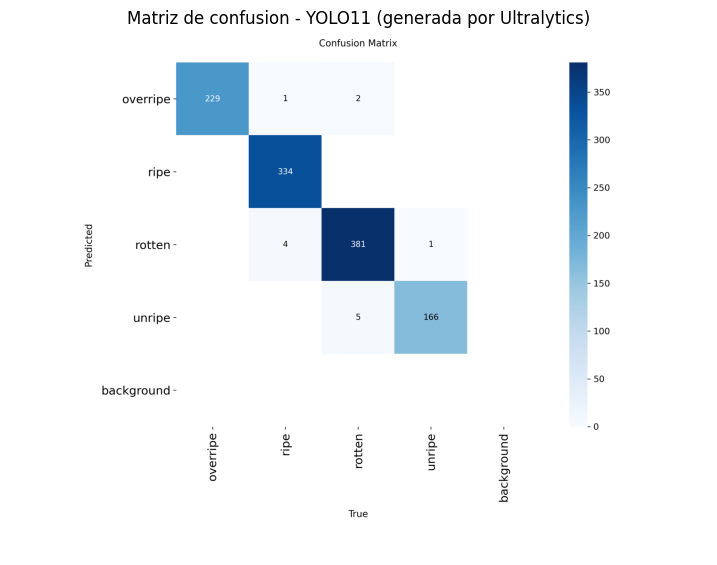

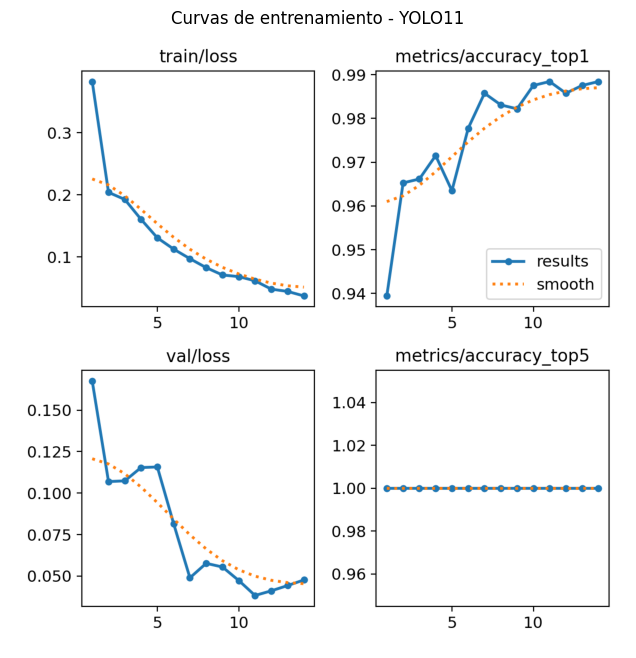


Evaluando YOLO sobre las 562 imagenes de test (formato comparable)...

Accuracy global YOLO: 0.9893 (98.9%)
Tiempo total: 10.0s | Tiempo por imagen: 17.8 ms

REPORTE DE CLASIFICACION (YOLO11)
              precision    recall  f1-score   support

       Verde      0.982     1.000     0.991       110
      Maduro      0.987     0.994     0.990       154
 Sobremaduro      1.000     0.982     0.991       113
     Podrido      0.989     0.984     0.986       185

    accuracy                          0.989       562
   macro avg      0.990     0.990     0.990       562
weighted avg      0.989     0.989     0.989       562



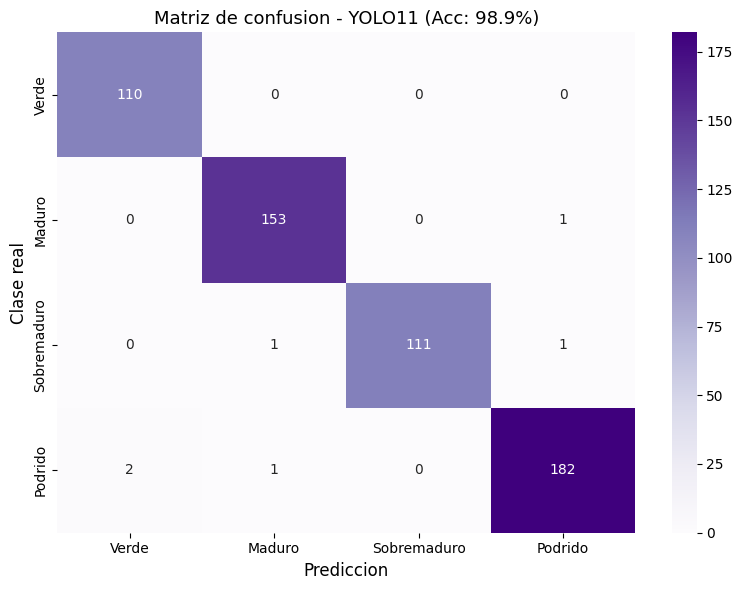


Resultados de YOLO guardados.


In [ ]:
# ============================================================
# BLOQUE 4: Evaluacion de YOLO sobre el test set + graficos
# ============================================================
from PIL import Image

# --- 1. Mostrar los graficos que YOLO genero automaticamente ---
rutaResultados = "/content/runs_yolo/platanos"
print("Graficos generados automaticamente por YOLO:\n")

# Matriz de confusion de YOLO (normalizada)
rutaMatrizYolo = os.path.join(rutaResultados, "confusion_matrix.png")
if os.path.exists(rutaMatrizYolo):
    img = Image.open(rutaMatrizYolo)
    plt.figure(figsize=(9, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Matriz de confusion - YOLO11 (generada por Ultralytics)")
    plt.show()

# Curvas de entrenamiento
rutaCurvas = os.path.join(rutaResultados, "results.png")
if os.path.exists(rutaCurvas):
    img = Image.open(rutaCurvas)
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Curvas de entrenamiento - YOLO11")
    plt.show()

# --- 2. Evaluacion manual sobre test set (mismo formato que los otros modelos) ---
print("\n" + "=" * 60)
print("Evaluando YOLO sobre las 562 imagenes de test (formato comparable)...")
print("=" * 60 + "\n")

yRealYOLO = []
yPredYOLO = []
tiempoInicio = time.time()

for clase in clases:
    rutaClase = os.path.join(rutaYolo, "test", clase)
    archivos = [a for a in os.listdir(rutaClase)
                if a.lower().endswith((".jpg", ".jpeg", ".png"))]
    for nombreArchivo in archivos:
        rutaImg = os.path.join(rutaClase, nombreArchivo)
        # Predecir con YOLO
        resultado = modeloYOLO.predict(rutaImg, verbose=False)
        idxPred = resultado[0].probs.top1  # indice de la clase mas probable
        nombrePred = resultado[0].names[idxPred]  # nombre de la clase
        yRealYOLO.append(clase)
        yPredYOLO.append(nombrePred)

tiempoTotal = time.time() - tiempoInicio

# --- 3. Metricas ---
accYOLO = accuracy_score(yRealYOLO, yPredYOLO)
print(f"Accuracy global YOLO: {accYOLO:.4f} ({accYOLO*100:.1f}%)")
print(f"Tiempo total: {tiempoTotal:.1f}s | Tiempo por imagen: {tiempoTotal/len(yRealYOLO)*1000:.1f} ms\n")

nombresOrden = [nombresEspanol[c] for c in clases]
print("=" * 60)
print("REPORTE DE CLASIFICACION (YOLO11)")
print("=" * 60)
print(classification_report(yRealYOLO, yPredYOLO, labels=clases,
                            target_names=nombresOrden, digits=3, zero_division=0))

# --- 4. Matriz de confusion en nuestro formato (para que combine con los otros) ---
matrizYOLO = confusion_matrix(yRealYOLO, yPredYOLO, labels=clases)
plt.figure(figsize=(8, 6))
sns.heatmap(matrizYOLO, annot=True, fmt="d", cmap="Purples",
            xticklabels=nombresOrden, yticklabels=nombresOrden)
plt.xlabel("Prediccion", fontsize=12)
plt.ylabel("Clase real", fontsize=12)
plt.title(f"Matriz de confusion - YOLO11 (Acc: {accYOLO*100:.1f}%)", fontsize=13)
plt.tight_layout()
plt.show()

# Guardar resultados
resultadosYOLO = {"accuracy": accYOLO, "yReal": yRealYOLO, "yPred": yPredYOLO,
                  "tiempoPorImagen_ms": tiempoTotal/len(yRealYOLO)*1000}
print("\nResultados de YOLO guardados.")

Sube una foto de un platano (boton abajo):



Saving WhatsApp Image 2026-06-30 at 8.28.54 PM.jpeg to WhatsApp Image 2026-06-30 at 8.28.54 PM.jpeg


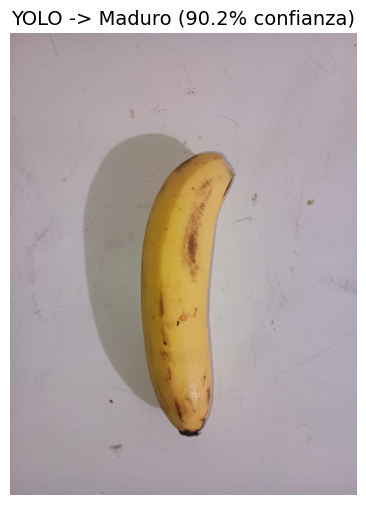

  CLASIFICACION (YOLO): Maduro  (confianza 90.2%)

  Apto para consumo:  Apto para consumo inmediato
  Ventana transporte: 3-7 dias
  Mercado recomendado: Mercados regionales / Consumo directo
  Observacion:        Estado optimo para venta al consumidor.

  Probabilidades por clase:
    Sobremaduro   :   0.0%  
    Maduro        :  90.2%  ###########################
    Podrido       :   9.8%  ##
    Verde         :   0.0%  


In [ ]:
# ============================================================
# BLOQUE 5: Probar YOLO con una foto propia
# ============================================================
from google.colab import files

# Info logistica por clase (basada en el caso de uso del informe)
infoLogistica = {
    "unripe": {"etiqueta": "VERDE", "apto": "No apto para consumo inmediato (requiere maduracion)",
               "ventana": "7-14 dias", "mercado": "Mercados lejanos / Exportacion",
               "obs": "Resistente al transporte. Puede madurar en destino."},
    "ripe": {"etiqueta": "MADURO", "apto": "Apto para consumo inmediato",
             "ventana": "3-7 dias", "mercado": "Mercados regionales / Consumo directo",
             "obs": "Estado optimo para venta al consumidor."},
    "overripe": {"etiqueta": "SOBREMADURO", "apto": "Apto, preferible para procesamiento industrial",
                 "ventana": "1-2 dias", "mercado": "Mercado local / Industria (pures, harina)",
                 "obs": "Alto riesgo de perdida. Comercializar con urgencia."},
    "rotten": {"etiqueta": "PODRIDO", "apto": "NO apto para consumo",
               "ventana": "0 dias (desecho)", "mercado": "Ninguno",
               "obs": "Separar del lote para evitar contaminacion."}
}

print("Sube una foto de un platano (boton abajo):\n")
subida = files.upload()
nombreArchivo = list(subida.keys())[0]

# Predecir con YOLO
resultado = modeloYOLO.predict(nombreArchivo, verbose=False)
probs = resultado[0].probs
idxClase = probs.top1
claseIngles = resultado[0].names[idxClase]
claseEspanol = nombresEspanol[claseIngles]
confianza = probs.top1conf.item() * 100
info = infoLogistica[claseIngles]

# Mostrar imagen + resultado
import cv2
imgMostrar = cv2.imread(nombreArchivo)
imgMostrar = cv2.cvtColor(imgMostrar, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(6, 6))
plt.imshow(imgMostrar)
plt.axis("off")
plt.title(f"YOLO -> {claseEspanol} ({confianza:.1f}% confianza)", fontsize=14)
plt.show()

# Reporte
print("=" * 55)
print(f"  CLASIFICACION (YOLO): {claseEspanol}  (confianza {confianza:.1f}%)")
print("=" * 55)
print(f"\n  Apto para consumo:  {info['apto']}")
print(f"  Ventana transporte: {info['ventana']}")
print(f"  Mercado recomendado: {info['mercado']}")
print(f"  Observacion:        {info['obs']}")

# Probabilidades de las 4 clases
print(f"\n  Probabilidades por clase:")
todasProbs = probs.data.tolist()  # lista con las 4 probabilidades
for i, nombreClaseYolo in resultado[0].names.items():
    p = todasProbs[i] * 100
    barra = "#" * int(todasProbs[i] * 30)
    print(f"    {nombresEspanol[nombreClaseYolo]:14s}: {p:5.1f}%  {barra}")

In [ ]:
# ============================================================
# BLOQUE 6: Guardar el modelo YOLO entrenado en Drive
# ============================================================

# YOLO guardo automaticamente el mejor modelo aqui:
rutaBestYolo = "/content/runs_yolo/platanos/weights/best.pt"

# Verificar que existe y su tamano
tamanoMB = os.path.getsize(rutaBestYolo) / (1024 * 1024)
print(f"Modelo YOLO encontrado: {rutaBestYolo}")
print(f"Tamano: {tamanoMB:.1f} MB\n")

# --- Respaldar en Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

carpetaDrive = "/content/drive/MyDrive/TrabajoFinal_PI"
os.makedirs(carpetaDrive, exist_ok=True)

# Copiar con un nombre claro
destinoDrive = os.path.join(carpetaDrive, "modelo_platanos_yolo.pt")
shutil.copy(rutaBestYolo, destinoDrive)
print(f"Modelo YOLO respaldado en Drive: {destinoDrive}")

# --- Descargar a la PC tambien ---
from google.colab import files
print("\nDescargando el modelo YOLO a tu PC...")
files.download(rutaBestYolo)

print("\n" + "=" * 50)
print("Ahora tienes en tu Drive los DOS modelos:")
print("  - modelo_platanos_cnn.keras  (MobileNet)")
print("  - modelo_platanos_yolo.pt    (YOLO11)")
print("=" * 50)

Modelo YOLO encontrado: /content/runs_yolo/platanos/weights/best.pt
Tamano: 3.0 MB

Mounted at /content/drive
Modelo YOLO respaldado en Drive: /content/drive/MyDrive/TrabajoFinal_PI/modelo_platanos_yolo.pt

Descargando el modelo YOLO a tu PC...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Ahora tienes en tu Drive los DOS modelos:
  - modelo_platanos_cnn.keras  (MobileNet)
  - modelo_platanos_yolo.pt    (YOLO11)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modelo CNN (MobileNet) cargado desde Drive.

Sube la foto del platano (la de 1 solo platano):



Saving WhatsApp Image 2026-06-30 at 8.28.54 PM.jpeg to WhatsApp Image 2026-06-30 at 8.28.54 PM (1).jpeg


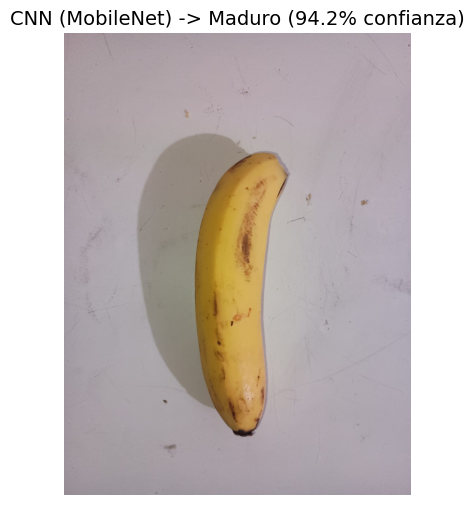

  CLASIFICACION (CNN): Maduro  (confianza 94.2%)

  Probabilidades por clase:
    Verde         :   0.5%  
    Maduro        :  94.2%  ############################
    Sobremaduro   :   0.0%  
    Podrido       :   5.3%  #


In [ ]:
# ============================================================
# BLOQUE EXTRA: Cargar el modelo CNN (MobileNet) y probarlo aqui
# ============================================================

# --- 1. Importar Keras y cargar el modelo CNN desde Drive ---
from tensorflow.keras.models import load_model
from google.colab import files
import cv2

# Montar Drive si no esta montado
from google.colab import drive
drive.mount('/content/drive')

# Cargar el modelo CNN que guardaste antes
rutaCNN = "/content/drive/MyDrive/TrabajoFinal_PI/modelo_platanos_cnn.keras"
modeloCNN = load_model(rutaCNN)
print("Modelo CNN (MobileNet) cargado desde Drive.\n")

# --- 2. Subir la foto y probar ---
print("Sube la foto del platano (la de 1 solo platano):\n")
subida = files.upload()
nombreArchivo = list(subida.keys())[0]

# Preprocesar igual que en el entrenamiento del CNN
imgOriginal = cv2.imread(nombreArchivo)
imgOriginal = cv2.cvtColor(imgOriginal, cv2.COLOR_BGR2RGB)
img = cv2.resize(imgOriginal, (224, 224)).astype("float32") / 255.0
img = np.expand_dims(img, axis=0)

# Predecir con el CNN
probs = modeloCNN.predict(img, verbose=0)[0]
idxClase = np.argmax(probs)
claseIngles = clases[idxClase]
claseEspanol = nombresEspanol[claseIngles]
confianza = probs[idxClase] * 100

# Mostrar
plt.figure(figsize=(6, 6))
plt.imshow(imgOriginal)
plt.axis("off")
plt.title(f"CNN (MobileNet) -> {claseEspanol} ({confianza:.1f}% confianza)", fontsize=14)
plt.show()

print("=" * 55)
print(f"  CLASIFICACION (CNN): {claseEspanol}  (confianza {confianza:.1f}%)")
print("=" * 55)
print(f"\n  Probabilidades por clase:")
for i, c in enumerate(clases):
    barra = "#" * int(probs[i] * 30)
    print(f"    {nombresEspanol[c]:14s}: {probs[i]*100:5.1f}%  {barra}")

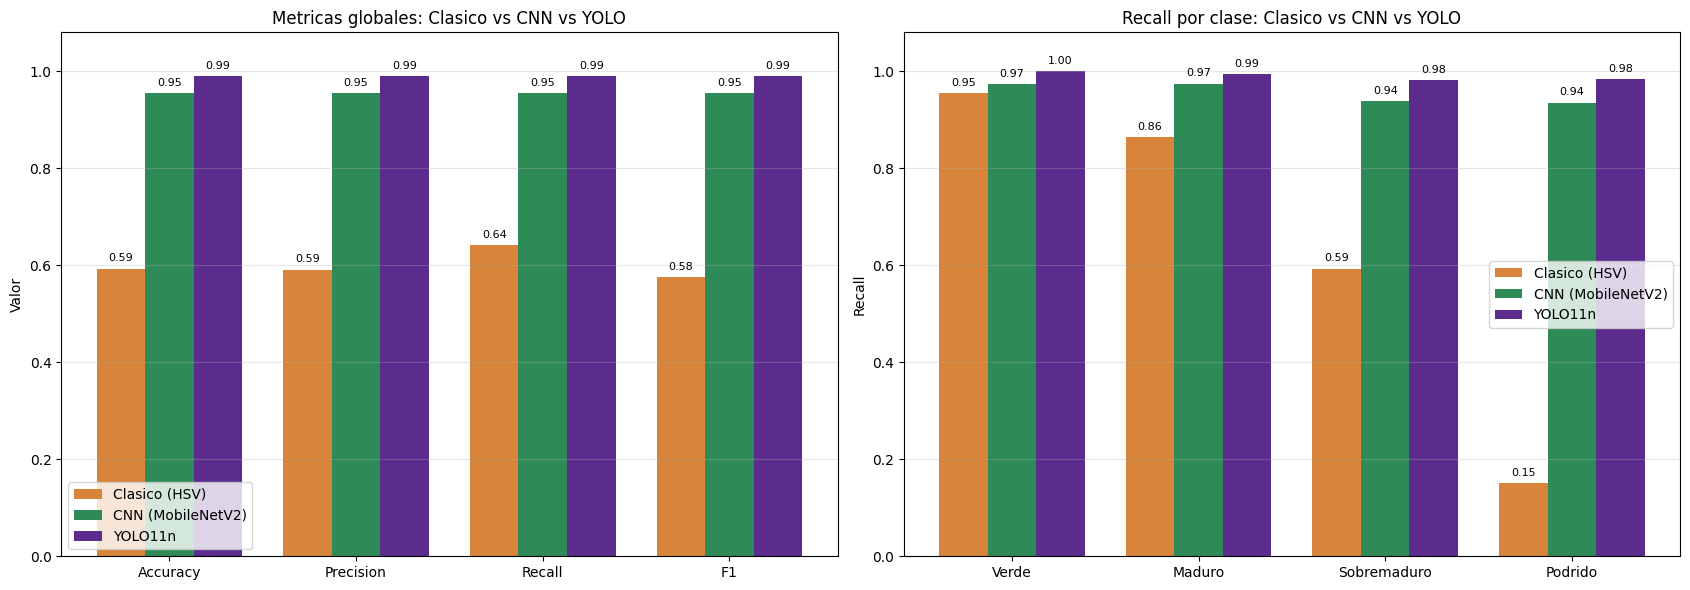

Figura 1 guardada: comparacion_3modelos.png


In [ ]:
# ============================================================
# BLOQUE FINAL: Comparacion de los TRES modelos (para el informe)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# --- Resultados de los tres modelos (valores obtenidos en las evaluaciones) ---
# Metricas globales macro
metricas = ["Accuracy", "Precision", "Recall", "F1"]
clasico_glob = [0.593, 0.591, 0.641, 0.576]
cnn_glob     = [0.954, 0.954, 0.955, 0.954]
yolo_glob    = [0.989, 0.990, 0.990, 0.990]

# Recall por clase
clasesNom = ["Verde", "Maduro", "Sobremaduro", "Podrido"]
clasico_rec = [0.955, 0.864, 0.593, 0.151]
cnn_rec     = [0.973, 0.974, 0.938, 0.935]
yolo_rec    = [1.000, 0.994, 0.982, 0.984]

# Colores (uno por modelo)
colClasico = "#D8843A"  # naranja
colCNN     = "#2E8B57"  # verde
colYOLO    = "#5B2C8D"  # morado

# --- Grafico 1: metricas globales (3 modelos) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 6))

x = np.arange(len(metricas))
ancho = 0.26
ax1.bar(x - ancho, clasico_glob, ancho, label="Clasico (HSV)", color=colClasico)
ax1.bar(x,          cnn_glob,     ancho, label="CNN (MobileNetV2)", color=colCNN)
ax1.bar(x + ancho,  yolo_glob,    ancho, label="YOLO11n", color=colYOLO)
ax1.set_xticks(x); ax1.set_xticklabels(metricas)
ax1.set_ylabel("Valor"); ax1.set_ylim(0, 1.08)
ax1.set_title("Metricas globales: Clasico vs CNN vs YOLO")
ax1.legend(); ax1.grid(axis="y", alpha=0.3)
for i in range(len(metricas)):
    ax1.text(i - ancho, clasico_glob[i] + 0.015, f"{clasico_glob[i]:.2f}", ha="center", fontsize=8)
    ax1.text(i,          cnn_glob[i] + 0.015,     f"{cnn_glob[i]:.2f}", ha="center", fontsize=8)
    ax1.text(i + ancho,  yolo_glob[i] + 0.015,    f"{yolo_glob[i]:.2f}", ha="center", fontsize=8)

# --- Grafico 2: recall por clase (3 modelos) ---
xc = np.arange(len(clasesNom))
ax2.bar(xc - ancho, clasico_rec, ancho, label="Clasico (HSV)", color=colClasico)
ax2.bar(xc,          cnn_rec,     ancho, label="CNN (MobileNetV2)", color=colCNN)
ax2.bar(xc + ancho,  yolo_rec,    ancho, label="YOLO11n", color=colYOLO)
ax2.set_xticks(xc); ax2.set_xticklabels(clasesNom)
ax2.set_ylabel("Recall"); ax2.set_ylim(0, 1.08)
ax2.set_title("Recall por clase: Clasico vs CNN vs YOLO")
ax2.legend(); ax2.grid(axis="y", alpha=0.3)
for i in range(len(clasesNom)):
    ax2.text(i - ancho, clasico_rec[i] + 0.015, f"{clasico_rec[i]:.2f}", ha="center", fontsize=8)
    ax2.text(i,          cnn_rec[i] + 0.015,     f"{cnn_rec[i]:.2f}", ha="center", fontsize=8)
    ax2.text(i + ancho,  yolo_rec[i] + 0.015,    f"{yolo_rec[i]:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("/content/comparacion_3modelos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura 1 guardada: comparacion_3modelos.png")

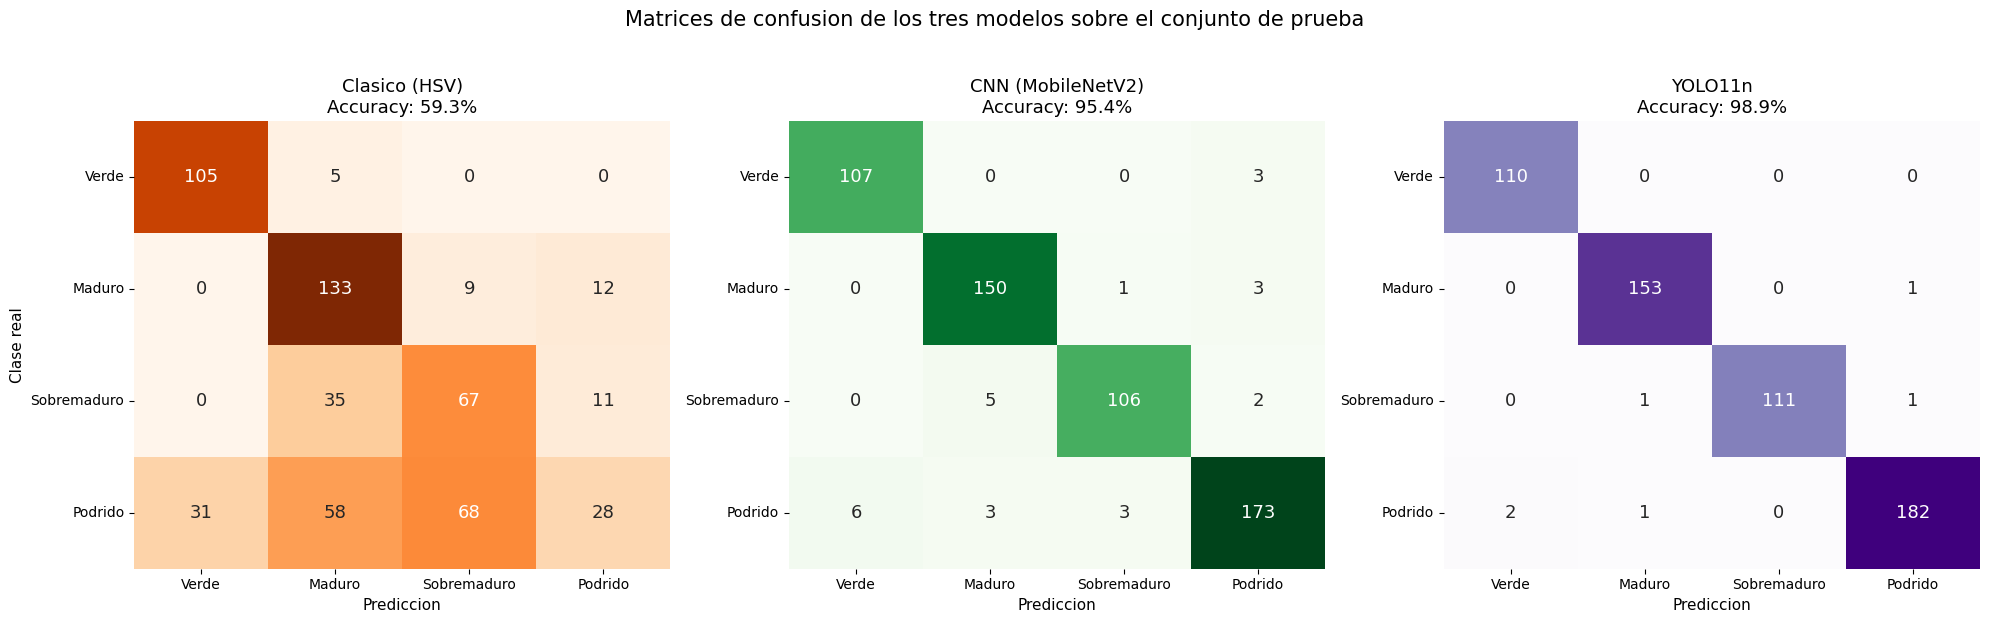

Figura 2 guardada: matrices_3modelos.png


In [ ]:
# ============================================================
# BLOQUE: Las TRES matrices de confusion juntas (Figura 2 del informe)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

clasesNom = ["Verde", "Maduro", "Sobremaduro", "Podrido"]

# Matrices de confusion de cada modelo (filas = clase real, columnas = prediccion)
# Valores obtenidos en las evaluaciones sobre el test set (562 imagenes)
matriz_clasico = np.array([
    [105,  5,  0,  0],   # Verde
    [  0,133,  9, 12],   # Maduro
    [  0, 35, 67, 11],   # Sobremaduro
    [ 31, 58, 68, 28],   # Podrido
])
matriz_cnn = np.array([
    [107,  0,  0,  3],   # Verde
    [  0,150,  1,  3],   # Maduro
    [  0,  5,106,  2],   # Sobremaduro
    [  6,  3,  3,173],   # Podrido
])
matriz_yolo = np.array([
    [110,  0,  0,  0],   # Verde
    [  0,153,  0,  1],   # Maduro
    [  0,  1,111,  1],   # Sobremaduro
    [  2,  1,  0,182],   # Podrido
])

# Accuracy de cada uno (para el titulo)
accs = {"Clasico (HSV)": 59.3, "CNN (MobileNetV2)": 95.4, "YOLO11n": 98.9}
matrices = [matriz_clasico, matriz_cnn, matriz_yolo]
titulos = list(accs.keys())
cmaps = ["Oranges", "Greens", "Purples"]

# Dibujar las 3 en una sola figura (1 fila, 3 columnas)
fig, ejes = plt.subplots(1, 3, figsize=(20, 6))

for i, (matriz, titulo, cmap) in enumerate(zip(matrices, titulos, cmaps)):
    sns.heatmap(matriz, annot=True, fmt="d", cmap=cmap, cbar=False,
                xticklabels=clasesNom, yticklabels=clasesNom, ax=ejes[i],
                annot_kws={"size": 13})
    ejes[i].set_title(f"{titulo}\nAccuracy: {accs[titulo]:.1f}%", fontsize=13)
    ejes[i].set_xlabel("Prediccion", fontsize=11)
    if i == 0:
        ejes[i].set_ylabel("Clase real", fontsize=11)
    ejes[i].set_yticklabels(ejes[i].get_yticklabels(), rotation=0)

plt.suptitle("Matrices de confusion de los tres modelos sobre el conjunto de prueba",
             fontsize=15, y=1.03)
plt.tight_layout()
plt.savefig("/content/matrices_3modelos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura 2 guardada: matrices_3modelos.png")